In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
games_df = pd.read_parquet("games_dataset.parquet").drop(columns=['engine', 'depth', 'pv'])
moves_df = pd.read_parquet("moves_dataset.parquet")
df = moves_df.merge(games_df, on="game_id", suffixes=("_move","_game"))
df.head()

,game_id,move_number,phase,classification,time_spent,san,white,black,rating,accuracy,...,splendid,perfect,best,excellent,good,opening,inaccuracy,mistake,blunder,forced
0,00001,1,opening,Opening,0.1,e4,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
1,00001,3,opening,Best,1.4,exd5,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
2,00001,5,opening,Best,0.6,Nc3,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
3,00001,7,opening,Excellent,2.6,Nf3,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
4,00001,9,opening,Excellent,2.0,Bc4,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1


In [50]:
df.describe()

,move_number,time_spent,rating,accuracy,num_moves,splendid,perfect,best,excellent,good,opening,inaccuracy,mistake,blunder,forced
count,754.000000,754.000000,754.000000,754.000000,754.000000,754.0,754.000000,754.000000,754.000000,754.000000,754.000000,754.000000,754.000000,754.000000,754.000000
mean,36.509284,6.674403,1061.273210,76.917772,35.928382,0.0,1.592838,10.505305,8.775862,4.937666,1.936340,2.754642,2.384615,2.488064,0.553050
std,28.075605,7.258274,188.480876,12.230999,16.278704,0.0,1.123219,5.668402,8.287907,2.623337,1.268132,1.665847,1.775763,2.002784,0.839258
min,1.000000,0.100000,716.000000,41.800000,8.000000,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,1.600000,926.000000,74.500000,25.000000,0.0,1.000000,6.000000,4.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000
50%,31.000000,4.050000,1058.000000,78.700000,32.000000,0.0,1.000000,9.000000,7.000000,6.000000,1.000000,3.000000,2.000000,2.000000,0.000000
75%,50.000000,8.800000,1151.000000,83.900000,47.000000,0.0,2.000000,14.000000,10.500000,7.000000,3.000000,4.000000,4.000000,4.000000,1.000000
max,142.000000,43.800000,1395.000000,95.600000,71.000000,0.0,4.000000,22.000000,32.000000,10.000000,5.000000,6.000000,6.000000,7.000000,3.000000


In [51]:
PLAYER = 'rastone98'
total_games = len(games_df)
wins = ((games_df['white'] == PLAYER) & (games_df['result'] == '1-0')) | \
       ((games_df['black'] == PLAYER) & (games_df['result'] == '0-1'))
num_wins = wins.sum()
win_rate = num_wins / total_games * 100
print(f"Win rate generale di {PLAYER}: {win_rate:.2f}%")
player_games = games_df[(games_df['white'] == PLAYER) | (games_df['black'] == PLAYER)]

# aggiungi colonna outcome dal punto di vista del player
player_games['outcome'] = [
    'win'  if (r['white'] == PLAYER and r['result']=='1-0') or (r['black']==PLAYER and r['result']=='0-1')
    else 'loss' if (r['white']==PLAYER and r['result']=='0-1') or (r['black']==PLAYER and r['result']=='1-0')
    else 'draw'
    for i,r in player_games.iterrows()
]

# aggiungi colonna colore del player
player_games['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in player_games.iterrows()]

# raggruppa per colore e outcome, conta partite
summary = player_games.groupby(['color','outcome']).size().unstack(fill_value=0)

# calcola percentuali
summary_percent = round(summary.div(summary.sum(axis=1), axis=0) * 100, 2)

# stampa
print("Conteggio partite per colore e outcome:")
print(summary)

print("\nPercentuali partite per colore:")
print(summary_percent)

Win rate generale di rastone98: 42.31%
Conteggio partite per colore e outcome:
outcome  draw  loss  win
color                   
black       1     5    7
white       1     8    4

Percentuali partite per colore:
outcome  draw   loss    win
color                      
black    7.69  38.46  53.85
white    7.69  61.54  30.77


In [52]:
# aggiungi colonna outcome dal punto di vista del player
df['outcome'] = [
    'win'  if (r['white'] == PLAYER and r['result']=='1-0') or (r['black']==PLAYER and r['result']=='0-1')
    else 'loss' if (r['white'] == PLAYER and r['result']=='0-1') or (r['black']==PLAYER and r['result']=='1-0')
    else 'draw'
    for i,r in df.iterrows()
]

# seleziona colonne di interesse
errors_df = df[['outcome','inaccuracy','mistake','blunder','num_moves']]

# calcola media pesata per outcome
weighted_means_outcome = errors_df.groupby('outcome').apply(
    lambda x: pd.Series({
        'inaccuracy': (x['inaccuracy'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'mistake':   (x['mistake']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'blunder':   (x['blunder']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)

# arrotonda e visualizza
display(weighted_means_outcome.round(2).style.background_gradient('Reds', vmin=0, vmax=weighted_means_outcome.max().max()).format("{:.2f}"))

,inaccuracy,mistake,blunder
outcome,,,
draw,2.39,4.09,4.09
loss,2.47,3.39,4.19
win,3.80,1.41,1.48


In [53]:
# aggiungi colonna colore del player
df['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in df.iterrows()]

# seleziona solo colonne di interesse
errors_df = df[['color','inaccuracy','mistake','blunder','num_moves']]

# raggruppa per fase e colore, calcola media pesata
weighted_means_color = errors_df.groupby(['color']).apply(
    lambda x: pd.Series({
        'inaccuracy': (x['inaccuracy'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'mistake':   (x['mistake']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'blunder':   (x['blunder']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)

# visualizzazione con gradiente
display(weighted_means_color.style.background_gradient('Reds', vmin=0, vmax=weighted_means_color.max().max()).format("{:.2f}"))

,inaccuracy,mistake,blunder
color,,,
black,3.57,2.01,2.22
white,2.23,3.48,4.13


In [54]:
errors_df = df[['phase', 'inaccuracy','mistake', 'blunder', 'num_moves']]
weighted_means = errors_df.groupby('phase').apply(
    lambda x: pd.Series({
        'inaccuracy': (x['inaccuracy'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'mistake':   (x['mistake']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'blunder':   (x['blunder']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)
display(weighted_means.style.background_gradient('Reds', vmin=0, vmax=weighted_means.max().max()).format("{:.2f}"))

,inaccuracy,mistake,blunder
phase,,,
endgame,3.59,2.56,3.16
middlegame,2.81,2.74,2.95
opening,2.86,2.28,2.57


In [55]:
# aggiungi colonna colore del player
df['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in df.iterrows()]

# seleziona solo colonne di interesse
errors_df = df[['phase','color','inaccuracy','mistake','blunder','num_moves']]

# raggruppa per fase e colore, calcola media pesata
weighted_means_color = errors_df.groupby(['color','phase']).apply(
    lambda x: pd.Series({
        'inaccuracy': (x['inaccuracy'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'mistake':   (x['mistake']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'blunder':   (x['blunder']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)

# visualizzazione con gradiente
display(weighted_means_color.style.background_gradient('Reds', vmin=0, vmax=weighted_means_color.max().max()).format("{:.2f}"))

In [56]:
# aggiungi colonna outcome dal punto di vista del player
df['outcome'] = [
    'win'  if (r['white'] == PLAYER and r['result']=='1-0') or (r['black']==PLAYER and r['result']=='0-1')
    else 'loss' if (r['white'] == PLAYER and r['result']=='0-1') or (r['black']==PLAYER and r['result']=='1-0')
    else 'draw'
    for i,r in df.iterrows()
]

# aggiungi colonna colore
df['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in df.iterrows()]

# seleziona colonne di interesse
errors_df = df[['phase','color','outcome','inaccuracy','mistake','blunder','num_moves']]

# raggruppa per fase, colore e outcome e calcola media pesata
weighted_means_all = errors_df.groupby(['phase','color','outcome']).apply(
    lambda x: pd.Series({
        'inaccuracy': (x['inaccuracy'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'mistake':   (x['mistake']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'blunder':   (x['blunder']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)
# creiamo una colonna combinata colore + outcome
weighted_means_all = weighted_means_all.reset_index()
weighted_means_all['color_outcome'] = weighted_means_all['color'] + '_' + weighted_means_all['outcome']

# pivot: fase sulle colonne, colore+outcome sulle righe
pivot_df = weighted_means_all.pivot(index='color_outcome', columns='phase', values=['inaccuracy','mistake','blunder'])

# visualizza con gradiente e arrotondamento
display(
    pivot_df.round(2)
    .style
    .background_gradient('Reds', vmin=0, vmax=pivot_df.max().max())
    .format("{:.2f}")
)

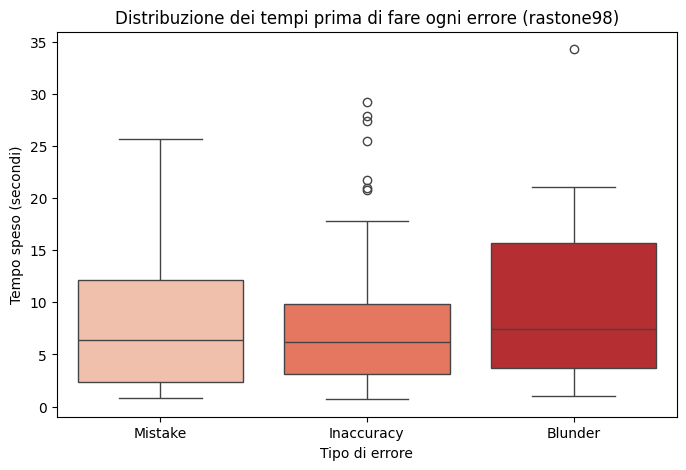

In [57]:
# boxplot: x = tipo di errore, y = tempo impiegato
error_moves = moves_df[moves_df['classification'].isin(['Inaccuracy','Mistake','Blunder'])]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=error_moves,
    x='classification',
    y='time_spent',
    hue='classification',    # aggiungi hue
    palette='Reds',
    dodge=False,             # evita duplicazioni
)
plt.ylabel("Tempo speso (secondi)")
plt.xlabel("Tipo di errore")
plt.title(f"Distribuzione dei tempi prima di fare ogni errore ({PLAYER})")
plt.show()

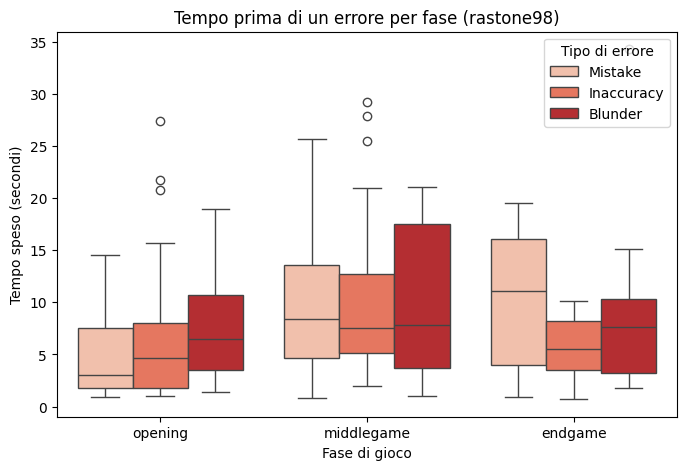

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# seleziona solo le mosse con errori
error_moves = moves_df[moves_df['classification'].isin(['Inaccuracy','Mistake','Blunder'])]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=error_moves,
    x='phase',
    y='time_spent',
    hue='classification',
    palette='Reds',
    dodge=True
)
plt.ylabel("Tempo speso (secondi)")
plt.xlabel("Fase di gioco")
plt.title(f"Tempo prima di un errore per fase ({PLAYER})")
plt.legend(title="Tipo di errore")
plt.show()

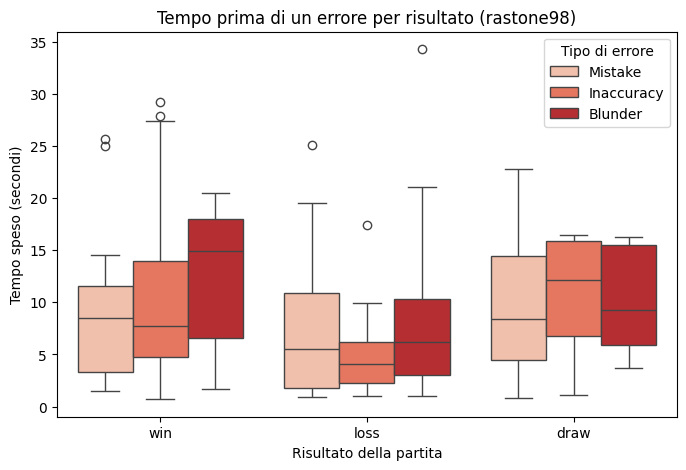

In [59]:
error_moves = df[df['classification'].isin(['Inaccuracy','Mistake','Blunder'])]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=error_moves,
    x='outcome',          # risultato della partita
    y='time_spent',       # tempo speso prima della mossa
    hue='classification', # tipo di errore
    palette='Reds',
    dodge=True
)
plt.ylabel("Tempo speso (secondi)")
plt.xlabel("Risultato della partita")
plt.title(f"Tempo prima di un errore per risultato ({PLAYER})")
plt.legend(title="Tipo di errore")
plt.show()

In [60]:
# seleziona le mosse buone
good_moves = df[df['classification'].isin(['Inaccuracy','Mistake','Blunder'])]

# tempo medio per tipo di mossa
good_time_means = good_moves.groupby('classification')['time_spent'].mean().round(2)
print("Tempo medio per tipo di errore:")
print(good_time_means)
error_counts = error_moves['classification'].value_counts()
error_percent = (error_counts / error_counts.sum() * 100).round(1)

print("Conteggio mosse d'errore:")
print(error_counts)
print("\nPercentuale mosse d'errore:")
print(error_percent)

Tempo medio per tipo di errore:
classification
Blunder       9.44
Inaccuracy    8.20
Mistake       8.15
Name: time_spent, dtype: float64
Conteggio mosse d'errore:
classification
Inaccuracy    63
Mistake       56
Blunder       54
Name: count, dtype: int64

Percentuale mosse d'errore:
classification
Inaccuracy    36.4
Mistake       32.4
Blunder       31.2
Name: count, dtype: float64


In [61]:
good_moves = df[df['classification'].isin(['Inaccuracy','Mistake','Blunder'])]

# media pesata per numero di mosse (qui useremo semplicemente il tempo)
weighted_good_time = good_moves.groupby(['phase','outcome']).apply(
    lambda x: (x['time_spent']).mean()
).round(2)

print("Tempo medio per fase e outcome (errori):")
print(weighted_good_time)

Tempo medio per fase e outcome (errori):
phase       outcome
endgame     draw       12.20
            loss        8.25
            win         6.35
middlegame  draw       10.60
            loss        8.42
            win        12.02
opening     draw        8.58
            loss        3.31
            win         9.16
dtype: float64


In [62]:
# trasformiamo le classificazioni in numerico per ranking qualitativo
rank_map = {'Blunder':1, 'Mistake':2, 'Inaccuracy':3}
df['move_rank'] = df['classification'].map(rank_map).fillna(0)

# correlazione tempo vs qualità
corr = df[['time_spent','move_rank']].corr().round(2)
print("Correlazione tempo vs qualità mossa (errori):")
print(corr)

Correlazione tempo vs qualità mossa (errori):
            time_spent  move_rank
time_spent        1.00       0.12
move_rank         0.12       1.00
